In [28]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
from optical.utils.test_utils import LoadDataset
from optical.surface import WaterSurface
from gsplat import rasterization

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
Dataset = LoadDataset()
Dataset.set_iamge(20)

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1376619].


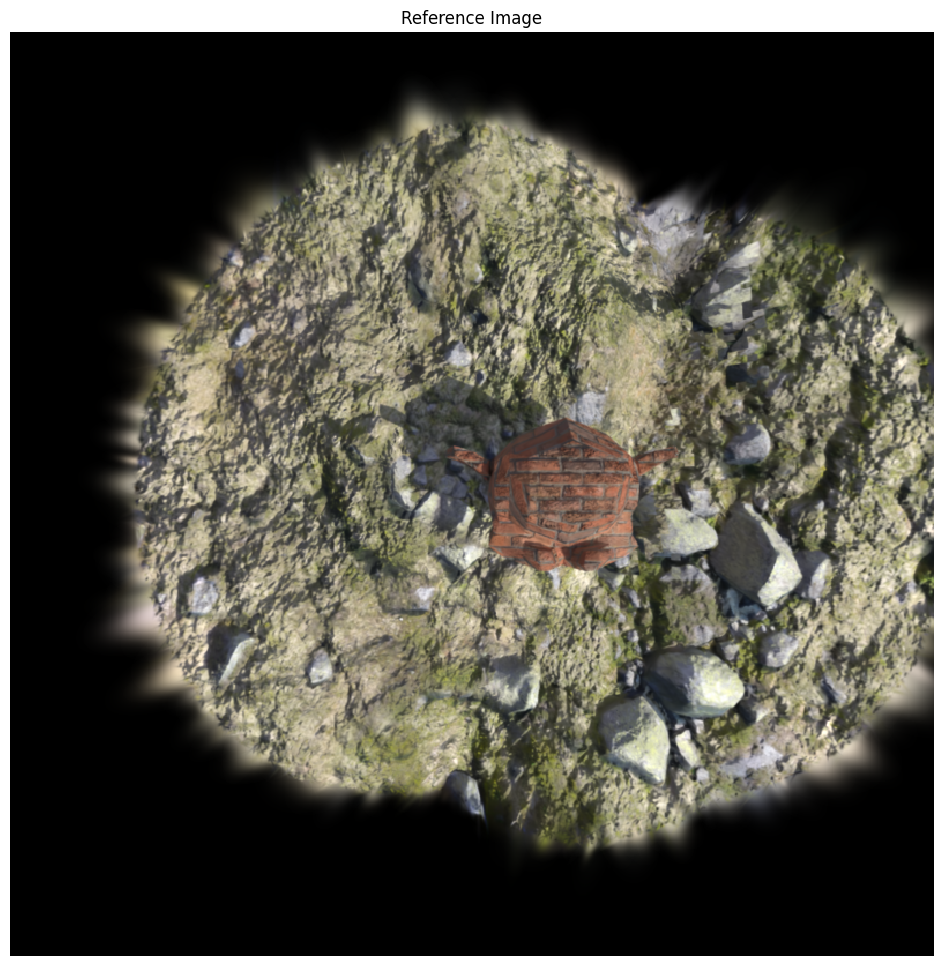

In [30]:
# Render
rgb_wo_ref, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_ref = rgb_wo_ref.squeeze().cpu().detach().numpy()

# Show the reference image
plt.imshow(rgb_wo_ref)
plt.axis('off')
plt.title('Reference Image')
plt.show()